In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

# Data Preprocessing

## 1. Handle missing value

In [3]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [4]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering 

In [5]:
# Age 
df["Age"] = 2026 - df["Year_Birth"]

# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [6]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [7]:
# Spending 
df["Total_spending"] = df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [8]:
# Children 
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [9]:
# Education 
df["Education"].value_counts()

# Under Graduate , Graduate ,PostGraduate

df["Education"] =df["Education"] .replace({
    "Basic" : "Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"PostGraduate",
    "PhD":"PostGraduate"
})


In [10]:
df["Education"].value_counts()

Education
Graduate         1127
PostGraduate      856
Undergraduate     257
Name: count, dtype: int64

In [11]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [12]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [13]:

df["Living_with"] =df["Marital_Status"] .replace({
    "Married" : "Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "YOLO":"Alone",
    "Absurd" : "Alone"
})


In [14]:
df["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

# Drop

In [15]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cols_to_drop =cols+spending_cols
df_cleaned = df.drop(columns = cols_to_drop)

In [16]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

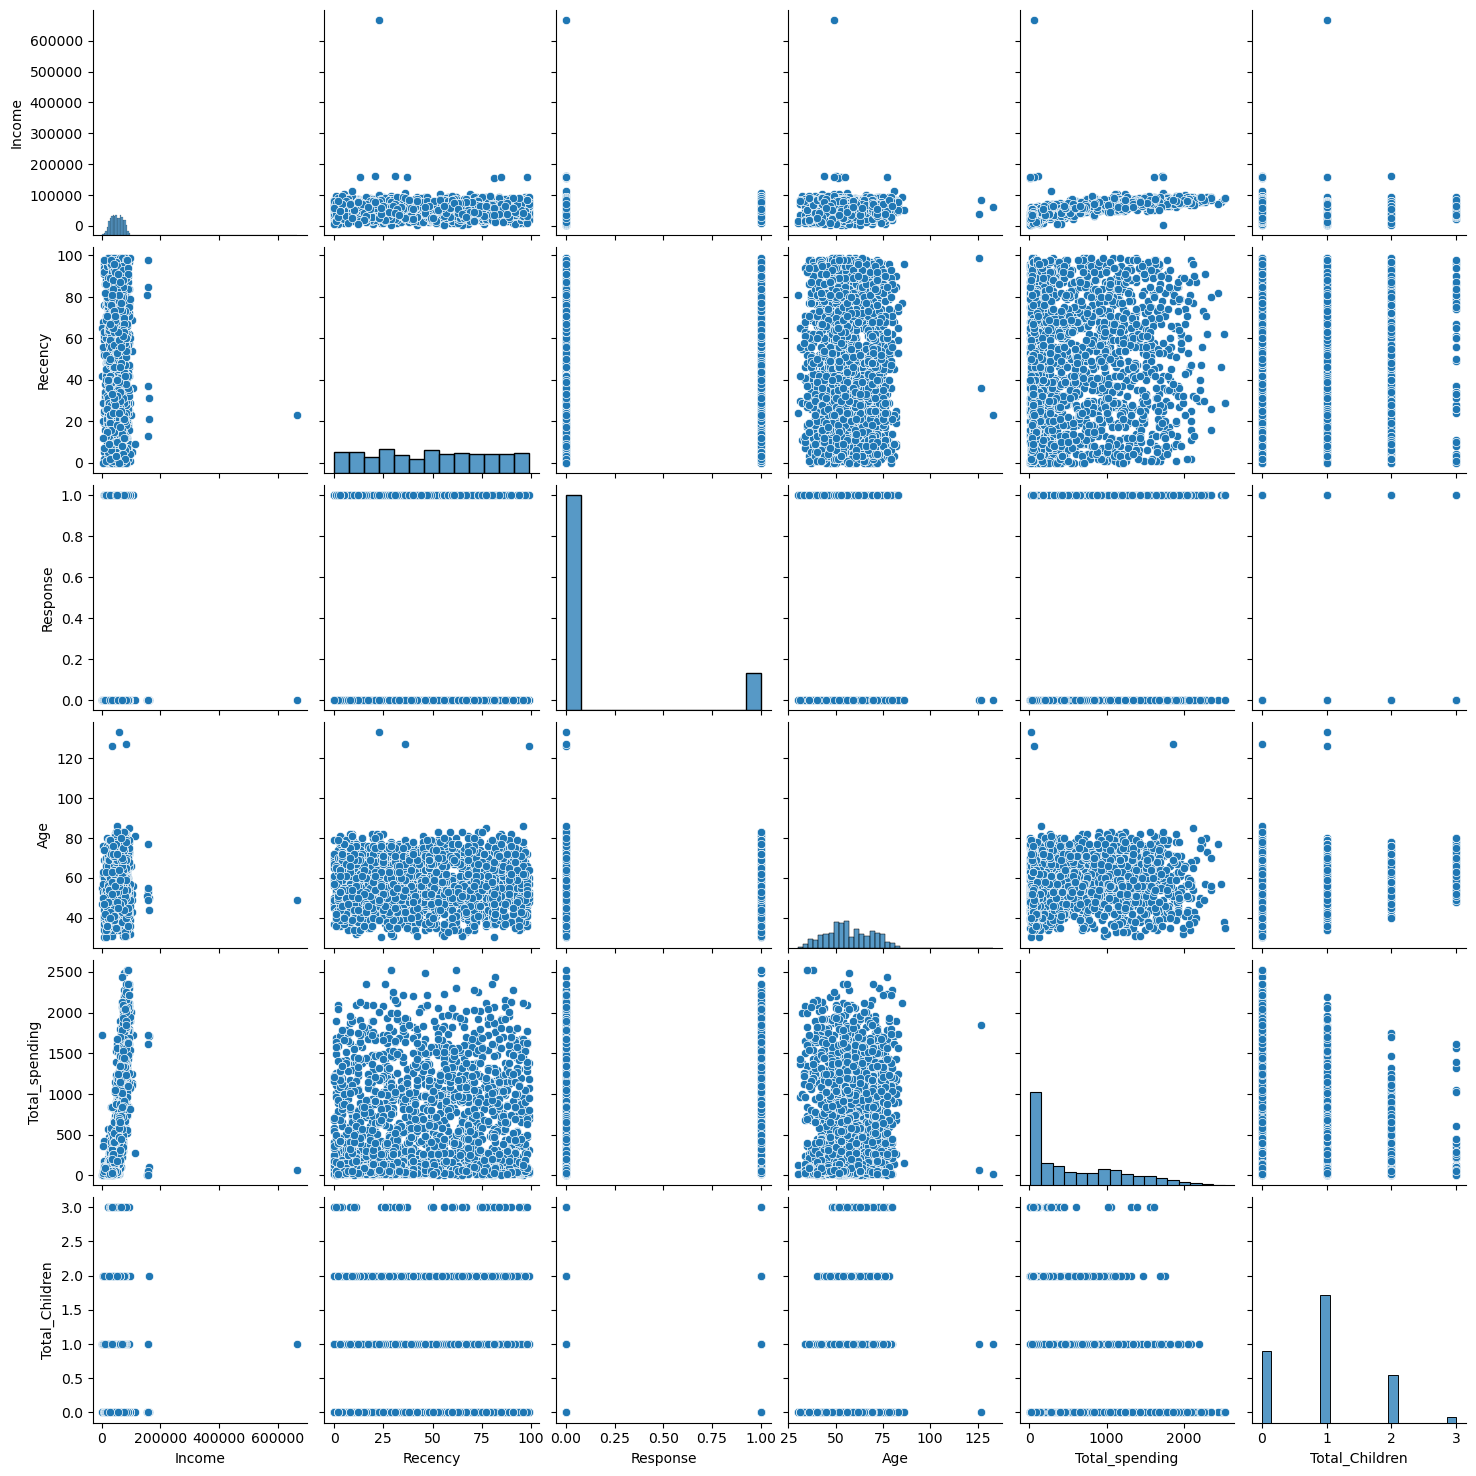

In [17]:
cols = ["Income","Recency","Response","Age","Total_spending","Total_Children"]

# Relatie plot pf sone features - Pair Plots

sns.pairplot(df_cleaned[cols])

In [18]:
# Remove Outlier 
df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]< 600_000)]

print("data size without outlier : ",len(df_cleaned))


data size without outlier :  2236


# Heatmap

In [19]:
corr = df_cleaned.corr(numeric_only = True)

In [20]:
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


<Axes: >

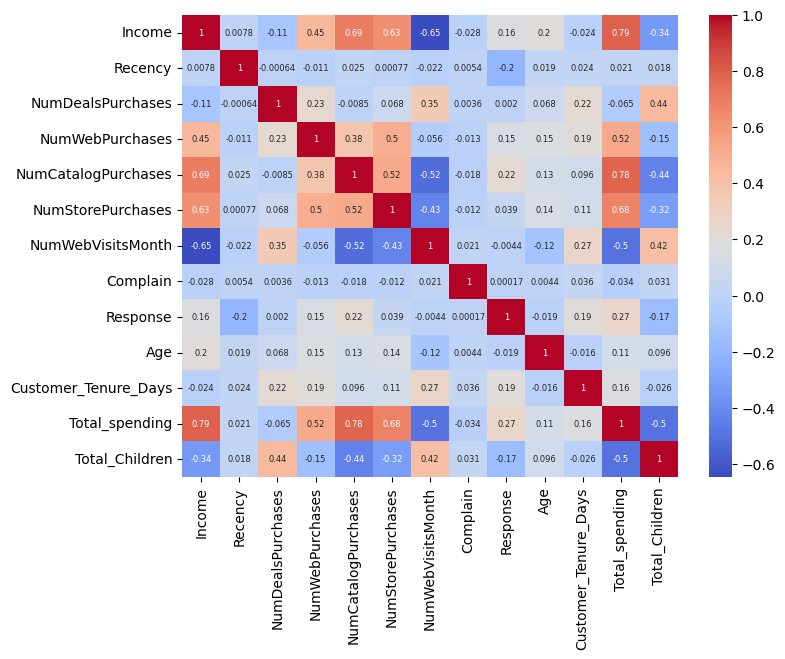

In [21]:
plt.figure(figsize = (8,6))

sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size":6},
    cmap = "coolwarm"
)

# Feature Encoding

In [22]:
from sklearn.preprocessing import OneHotEncoder

In [23]:
ohe = OneHotEncoder()

cat_cols = ["Education","Living_with"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [24]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns =ohe.get_feature_names_out(cat_cols),index = df_cleaned.index )

In [25]:
enc_df

,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
2235,1.0,0.0,0.0,0.0,1.0
2236,0.0,1.0,0.0,0.0,1.0
2237,1.0,0.0,0.0,1.0,0.0
2238,0.0,1.0,0.0,0.0,1.0


In [26]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols), enc_df],axis = 1)

# Scaling

In [30]:
from sklearn.preprocessing import StandardScaler 

In [31]:
X = df_encoded

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize

In [35]:
X_scaled.shape

(2236, 18)

In [37]:
# 2d

from sklearn.decomposition import PCA 

In [44]:
pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3d Projection')

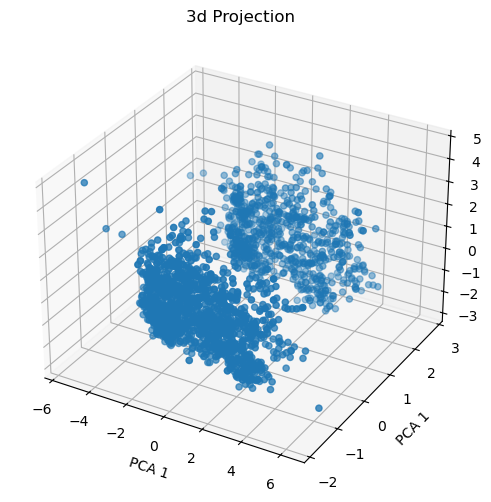

In [49]:
# plot
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection ="3d")
ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2]

)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 1")
ax.set_zlabel("PCA 3")
ax.set_title("3d Projection")

In [46]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analyze K value

### 1. Elbow Method

In [52]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k,random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [54]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction = "decreasing")
optimal_k = knee.elbow

In [55]:
print("Best k = ",optimal_k)

Best k =  4


Text(0, 0.5, 'WCSS')

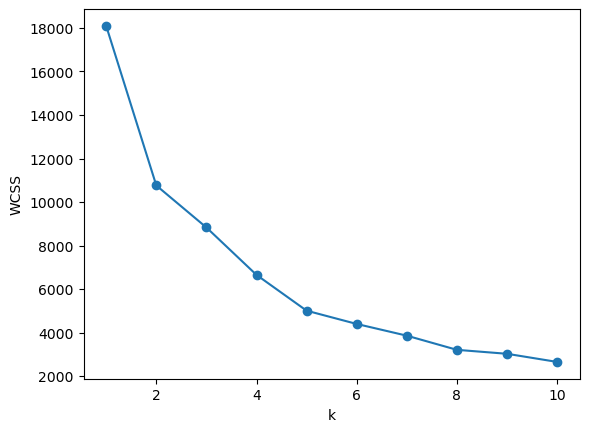

In [59]:
# Plot 

plt.plot(range(1,11),wcss,marker = "o")
plt.xlabel("k")
plt.ylabel("WCSS")

### 2. Silhouette Score

Text(0, 0.5, 'Silhouette_score')

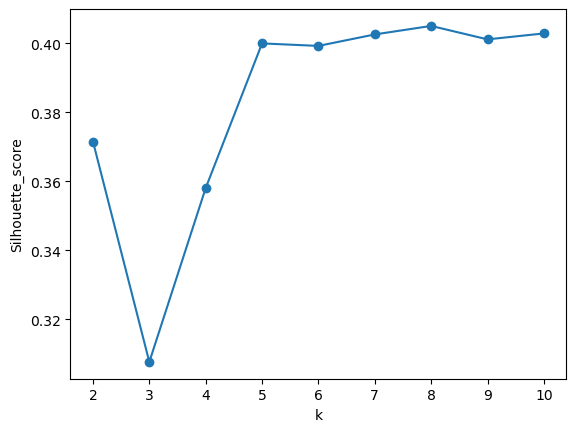

In [66]:
from sklearn.metrics import silhouette_score
scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters = k,random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

plt.plot(range(2,11),scores,marker = "o")
plt.xlabel("k")
plt.ylabel("Silhouette_score")

Text(0, 0.5, 'SS')

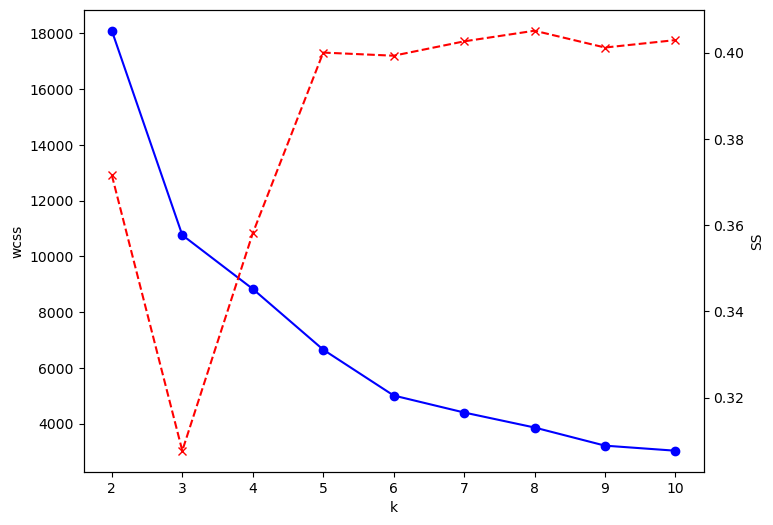

In [93]:
# Combined plot

k_range = range(2,11)

fig,ax1 = plt.subplots(figsize =(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker = "o",color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker = "x",color = "red",linestyle="--")
ax2.set_ylabel("SS")


# Clustering

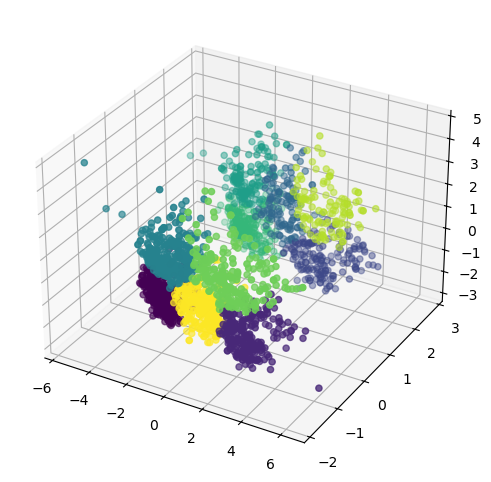

In [97]:
kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmenas = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection ="3d")
ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c = labels

)

In [99]:
# Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

In [101]:
agg_clf = AgglomerativeClustering(n_clusters = 4 , linkage ="ward")
labels_agg = agg_clf.fit_predict(X_pca)

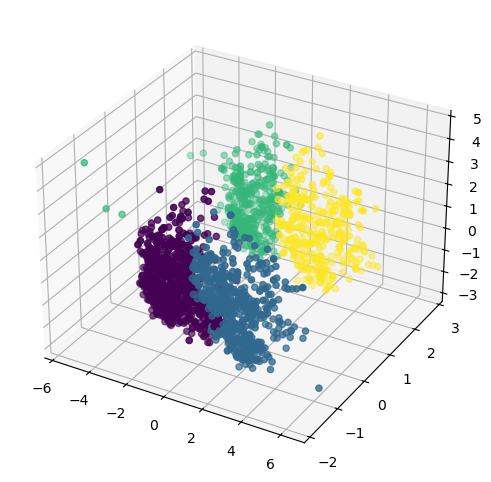

In [102]:
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection ="3d")
ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c = labels_agg

)

# Characterization of Clusters

In [117]:
X["clusters"] = labels_agg

In [118]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children,Living_with,labels,clusters
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0,0
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0,0


<Axes: xlabel='clusters', ylabel='count'>

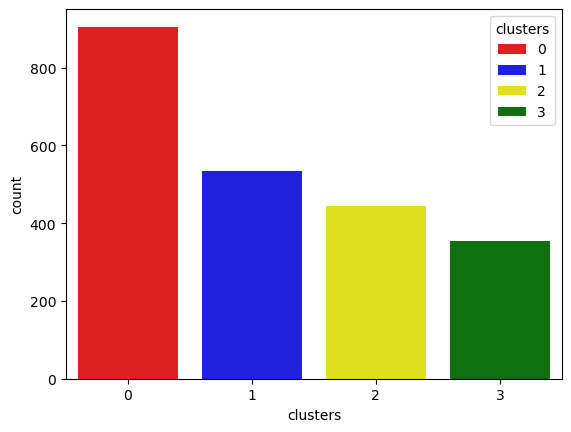

In [119]:
pal = ["red","blue","yellow","green"]

sns.countplot(x=df_cleaned["clusters"],palette = pal , hue =df_cleaned["clusters"])

<Axes: xlabel='Total_spending', ylabel='Income'>

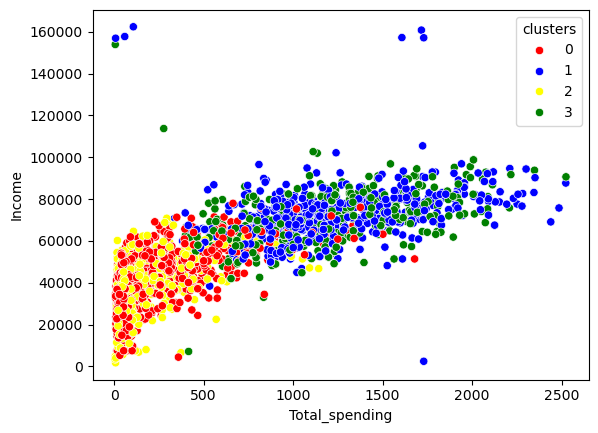

In [122]:
# Income & Spending Patterns 

sns.scatterplot(x = X["Total_spending"],y = X["Income"],hue = X["clusters"],palette=pal)

In [125]:
# Cluster Summary

cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_Days  Total_spending  \
clu